# Kreditriskmodell — Privatlån
**Syfte:** Bygga och validera en logistisk regressionsmodell för att förutsäga risken att en låntagare slutar betala sitt privatlån. Analysen följer ett strukturerat arbetsflöde från datainläsning till modellvalidering, i linje med krav under IFRS 9.

**Om privatlån:** Till skillnad från bolån har privatlån ingen säkerhet — banken kan inte ta en bostad om låntagaren slutar betala. Det gör kreditriskbedömningen viktigare och räntan högre (typiskt 5–25% jämfört med 2–5% för bolån).

**IFRS 9** är en internationell redovisningsstandard som banker måste följa. Den kräver att banker beräknar och reserverar pengar för förväntade kreditförluster samt att modellerna är tolkningsbara och dokumenterade.

**Författare:** Jasmin  
**Data:** Syntetisk privatlånsdata, 10 000 observationer  
**Verktyg:** Python, scikit-learn, pandas, seaborn, matplotlib

## 1. Import av bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

## 2. Datainläsning

I produktion hämtas data från BigQuery via:
```sql
SELECT lanebelopp, inkomst, alder, anstallningsform, syfte,
       ranta, amorteringstid_manader, skuldsattningsgrad,
       manadskostnad, betalningsborda, tidigare_anmarkning, default
FROM `medmera.kreditrisk.privatlan_data`
```

I detta exempel används lokal CSV med syntetisk data för demonstration.
I en produktionsmiljö ersätts `pd.read_csv()` med en BigQuery-koppling via `google-cloud-bigquery`.
Modellen skulle tränas och driftsättas i Vertex AI på Google Cloud Platform.

In [2]:
df = pd.read_csv('privatlan_data.csv')
print(f"Laddade {len(df):,} rader och {df.shape[1]} kolumner")
df.head()

Laddade 10,000 rader och 12 kolumner


,lanebelopp,inkomst,alder,anstallningsform,syfte,ranta,amorteringstid_manader,skuldsattningsgrad,manadskostnad,betalningsborda,tidigare_anmarkning,default
0,306000,290467,31,Fast anställd,Konsumtion,9.71,24,1.05,14079,0.582,nej,0
1,254000,150046,31,Arbetslös,Renovering,12.63,36,1.69,8513,0.681,nej,1
2,329000,537352,27,Egenföretagare,Bil,9.63,24,0.61,15126,0.338,nej,0
3,320000,240180,29,Vikariat,Bil,7.43,12,1.33,27752,1.387,nej,1
4,500000,721741,42,Fast anställd,Konsumtion,9.86,60,0.69,10589,0.176,nej,0


## 3. Explorativ analys
Innan modellering undersöker vi fördelningar och samband i datan.

**Betalningsstatus** är målvariabeln — det vi försöker förutsäga:
- **0** = låntagaren sköter sina betalningar
- **1** = låntagaren har slutat betala

Datan är syntetiskt skapad med realistiska riskfaktorer:
- Hög skuldsättningsgrad och hög betalningsbörda ökar risken
- Arbetslösa och vikariatsanställda har högre risk
- Tidigare betalningsanmärkning ökar risken markant
- Konsumtionslån har något högre risk än renoveringslån

In [3]:
print("Statistisk sammanfattning:")
df.describe().round(2)

Statistisk sammanfattning:


,lanebelopp,inkomst,alder,ranta,amorteringstid_manader,skuldsattningsgrad,manadskostnad,betalningsborda,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,368265.70,453544.92,40.19,10.64,41.10,0.88,13357.29,0.39,0.26
std,136956.85,201459.09,12.93,3.09,18.13,0.35,9058.94,0.27,0.44
min,38000.00,120000.00,18.00,4.00,12.00,0.30,847.00,0.06,0.00
25%,251000.00,305894.00,31.00,8.51,24.00,0.61,7505.75,0.21,0.00
50%,407000.00,420773.00,39.00,10.43,36.00,0.84,11193.50,0.31,0.00
75%,500000.00,563707.00,47.00,12.46,48.00,1.12,16202.00,0.47,1.00
max,500000.00,1200000.00,84.00,25.00,84.00,1.79,46449.00,1.92,1.00


In [16]:
# Andel som slutat betala per anställningsform
# Visar hur anställningsform påverkar betalningsrisken
andel_per_anstallning = (df.groupby('anstallningsform')['default']
                           .agg(['mean', 'count'])
                           .rename(columns={'mean': 'andel_slutat_betala', 'count': 'antal'})
                           .sort_values('andel_slutat_betala', ascending=False)
                           .reset_index())

# Omvandla från decimaltal till procent
andel_per_anstallning['andel_slutat_betala'] = (
    andel_per_anstallning['andel_slutat_betala'] * 100
).round(1)

print("Andel uteblivna betalningar per anställningsform (%):")
andel_per_anstallning

Andel uteblivna betalningar per anställningsform (%):


,anstallningsform,andel_slutat_betala,antal
0,Arbetslös,56.1,786
1,Vikariat,34.2,1507
2,Pensionär,26.6,952
3,Egenföretagare,23.7,1149
4,Fast anställd,20.0,5606


In [17]:
# Andel som slutat betala per syfte med lånet
andel_per_syfte = (df.groupby('syfte')['default']
                     .agg(['mean', 'count'])
                     .rename(columns={'mean': 'andel_slutat_betala', 'count': 'antal'})
                     .sort_values('andel_slutat_betala', ascending=False)
                     .reset_index())

andel_per_syfte['andel_slutat_betala'] = (
    andel_per_syfte['andel_slutat_betala'] * 100
).round(1)

print("Andel uteblivna betalningar per syfte (%):")
andel_per_syfte

Andel uteblivna betalningar per syfte (%):


,syfte,andel_slutat_betala,antal
0,Konsumtion,29.1,3052
1,Renovering,25.0,2505
2,Övrigt,24.8,1965
3,Bil,24.3,2478


### 3.1 Korrelationsmatris
Korrelationsmatrisen visar hur starkt alla numeriska variabler samvarierar, på en skala från **-1 till +1**:

- **+1** = perfekt positivt samband (båda ökar tillsammans)
- **0** = inget samband  
- **-1** = perfekt negativt samband (en ökar när den andra minskar)

**Praktisk tumregel:**
- Värden över **0.3** eller under **-0.3** är värda att notera
- Värden över **0.7** betyder att variablerna nästan mäter samma sak — då kan man överväga att ta bort en av dem för att undvika att samma information räknas dubbelt

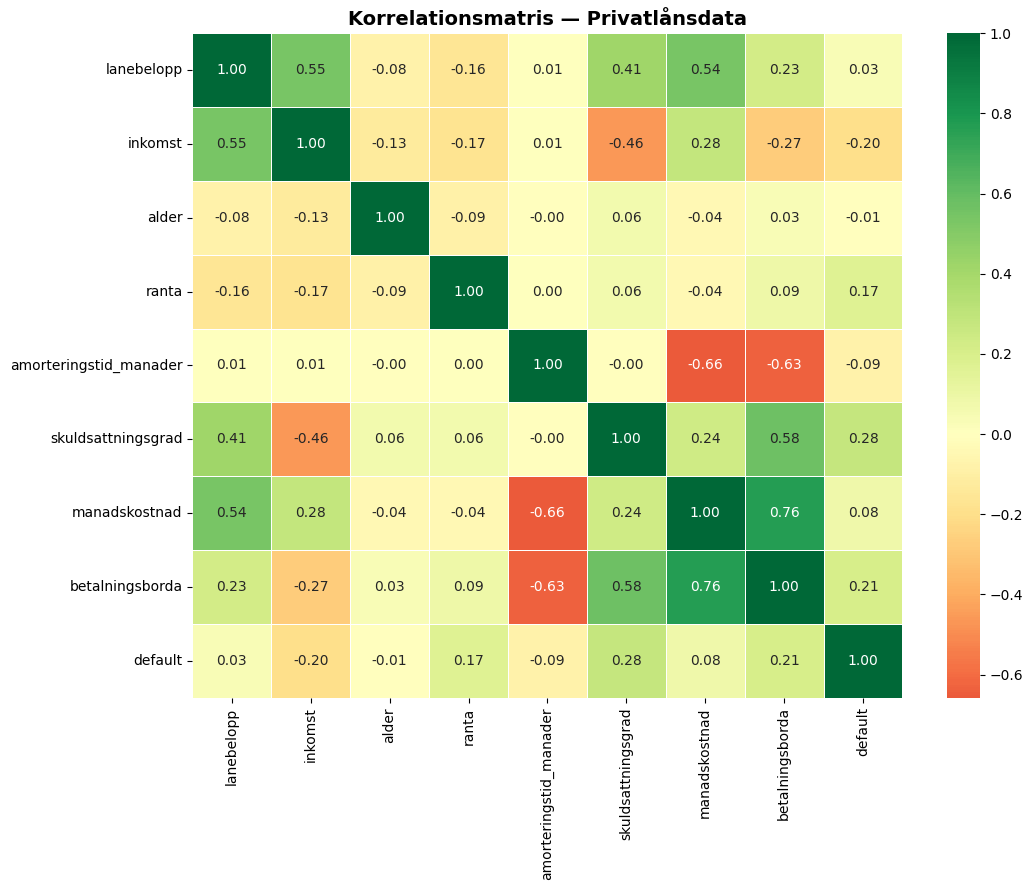

In [6]:
# Välj endast numeriska kolumner — korrelationsmatrisen kräver siffror
numerisk_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(11, 9))
sns.heatmap(
    numerisk_df.corr(),
    annot=True,          # Visa korrelationsvärdet i varje ruta
    fmt='.2f',           # Avrunda till två decimaler
    cmap='RdYlGn',       # Röd = negativt samband, gul = neutralt, grön = positivt
    linewidths=0.5,
    center=0
)
plt.title('Korrelationsmatris — Privatlånsdata', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Betalningsproblem per anställningsform
Visualiserar hur anställningsform påverkar risken — en av de viktigaste riskdrivarna för privatlån.

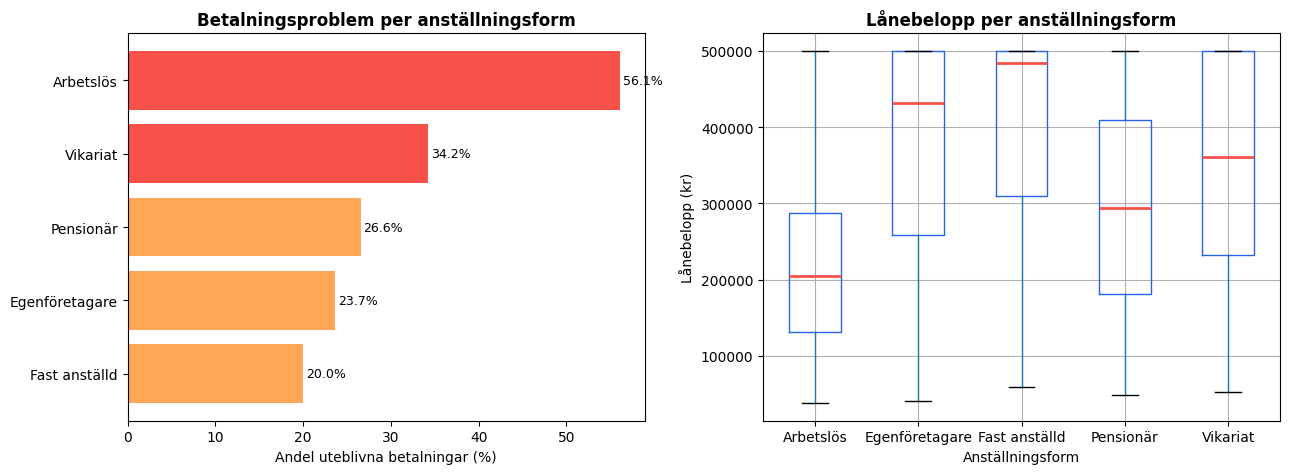

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Vänster: andel uteblivna betalningar per anställningsform
andel = (df.groupby('anstallningsform')['default']
           .mean()
           .sort_values(ascending=True) * 100)

colors = ['#3fb950' if v < 15 else '#ffa657' if v < 30 else '#f85149' for v in andel.values]
axes[0].barh(andel.index, andel.values, color=colors, edgecolor='none')
axes[0].set_xlabel('Andel uteblivna betalningar (%)')
axes[0].set_title('Betalningsproblem per anställningsform', fontweight='bold')
for i, v in enumerate(andel.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Höger: fördelning av lånebelopp per anställningsform
df.boxplot(column='lanebelopp', by='anstallningsform', ax=axes[1],
           boxprops=dict(color='#2563eb'),
           medianprops=dict(color='#f85149', linewidth=2))
axes[1].set_title('Lånebelopp per anställningsform', fontweight='bold')
axes[1].set_xlabel('Anställningsform')
axes[1].set_ylabel('Lånebelopp (kr)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Feature Engineering
Vi skapar variabler som fångar ekonomisk risk på ett mer direkt sätt än rådata:

- **betalningsborda**: Hur stor andel av månadsinkomsten går till lånebetalningen (>30% anses högrisk)
- **skuldsattningsgrad**: Lånebeloppet i förhållande till årsinkomsten
- Dessa variabler är redan beräknade i datan men vi verifierar och förklarar dem här

In [8]:
# Verifiera att betalningsbördan är korrekt beräknad
# Formel: månadskostnad / (inkomst / 12)
df['betalningsborda_check'] = (df['manadskostnad'] / (df['inkomst'] / 12)).round(3)

print("Betalningsbörda — beskrivande statistik:")
print(df['betalningsborda'].describe().round(3))
print()

# Visa andel låntagare med hög betalningsbörda (>30% av månadsinkomsten)
hog_borda = (df['betalningsborda'] > 0.30).mean()
print(f"Andel låntagare med betalningsbörda >30% av månadsinkomsten: {hog_borda:.1%}")
print(f"Snitt skuldsättningsgrad: {df['skuldsattningsgrad'].mean():.2f}×")

Betalningsbörda — beskrivande statistik:
count    10000.000
mean         0.387
std          0.273
min          0.055
25%          0.207
50%          0.312
75%          0.471
max          1.915
Name: betalningsborda, dtype: float64

Andel låntagare med betalningsbörda >30% av månadsinkomsten: 52.3%
Snitt skuldsättningsgrad: 0.88×


## 5. Modellträning
Vi använder logistisk regression eftersom den:
- Ger en **sannolikhet** (t.ex. 23% risk) istället för bara ja/nej
- Är **tolkningsbar** — varje variabels påverkan kan förklaras, vilket krävs för IFRS 9
- Är **branschstandard** inom kreditrisk och enkel att dokumentera för regulatorer

`class_weight='balanced'` används för att hantera att det finns fler skötsamma låntagare än riskfyllda — annars tenderar modellen att missa riskfyllda lån.

Kategoriska variabler (anställningsform, syfte) kodas om till siffror via one-hot encoding.

In [9]:
# One-hot encoding av kategoriska variabler
# Omvandlar t.ex. 'Fast anställd' till kolumner med 0/1
df_encoded = pd.get_dummies(df, columns=['anstallningsform', 'syfte'], drop_first=True)

# Konvertera boolean-kolumner till int (0/1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Kodifiera betalningsanmärkning: ja=1, nej=0
df_encoded['tidigare_anmarkning'] = (df_encoded['tidigare_anmarkning'] == 'ja').astype(int)

# Välj features
features = ['lanebelopp', 'inkomst', 'alder', 'ranta', 'amorteringstid_manader',
            'skuldsattningsgrad', 'manadskostnad', 'betalningsborda',
            'tidigare_anmarkning'] +            [c for c in df_encoded.columns if c.startswith('anstallningsform_') or c.startswith('syfte_')]

X = df_encoded[features]
y = df_encoded['default']

print(f"Antal features: {len(features)}")
print(f"Features: {features}")

Antal features: 16
Features: ['lanebelopp', 'inkomst', 'alder', 'ranta', 'amorteringstid_manader', 'skuldsattningsgrad', 'manadskostnad', 'betalningsborda', 'tidigare_anmarkning', 'anstallningsform_Egenföretagare', 'anstallningsform_Fast anställd', 'anstallningsform_Pensionär', 'anstallningsform_Vikariat', 'syfte_Konsumtion', 'syfte_Renovering', 'syfte_Övrigt']


In [10]:
# Dela upp i tränings- och testdata
# 80% träning, 20% test — fast random_state för reproducerbarhet
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Skala om variablerna så att de är på samma skala
# fit_transform på träningsdata, transform på testdata
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Träna modellen med class_weight='balanced' för att hantera obalanserad data
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

print(f"Träningsdata:                {len(X_train):,} observationer")
print(f"Testdata:                    {len(X_test):,} observationer")
print(f"Andel uteblivna betalningar: {y.mean():.1%}")

Träningsdata:                8,000 observationer
Testdata:                    2,000 observationer
Andel uteblivna betalningar: 26.0%


## 6. Modellvalidering
Vi utvärderar modellen med fyra kompletterande mått:
- **Gini-koefficient**: Branschstandard för kreditriskmodeller. > 0.4 är acceptabelt, > 0.6 är starkt
- **Klassificeringsrapport**: Visar träffsäkerhet och täckningsgrad per grupp
- **Konfusionsmatris**: Visar exakt hur många lån som klassificerades rätt respektive fel
- **ROC-kurva**: Visar modellens prestanda vid olika tröskelvärden

In [11]:
# Beräkna sannolikheten att varje låntagare slutar betala
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Modellens beslut vid 50% tröskel
y_pred = model.predict(X_test_scaled)

# AUC och Gini
auc  = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

print(f"ROC-AUC:          {auc:.3f}")
print(f"Gini-koefficient: {gini:.3f}")
print()

if gini > 0.6:
    print("✅ Mycket bra träffsäkerhet (Gini > 0.6)")
elif gini > 0.4:
    print("✅ Acceptabel träffsäkerhet (Gini > 0.4)")
else:
    print("⚠️  Svag träffsäkerhet — modellen bör förbättras")

print()
# Träffsäkerhet = hur ofta modellen har rätt när den flaggar ett lån som riskfyllt
# Täckningsgrad = hur stor andel av alla riskfyllda lån modellen lyckas fånga upp
print("Klassificeringsrapport:")
print(classification_report(y_test, y_pred, target_names=['Sköter betalningar', 'Slutat betala']))

ROC-AUC:          0.769
Gini-koefficient: 0.537

✅ Acceptabel träffsäkerhet (Gini > 0.4)

Klassificeringsrapport:
                    precision    recall  f1-score   support

Sköter betalningar       0.88      0.72      0.79      1487
     Slutat betala       0.47      0.72      0.56       513

          accuracy                           0.72      2000
         macro avg       0.67      0.72      0.68      2000
      weighted avg       0.77      0.72      0.73      2000



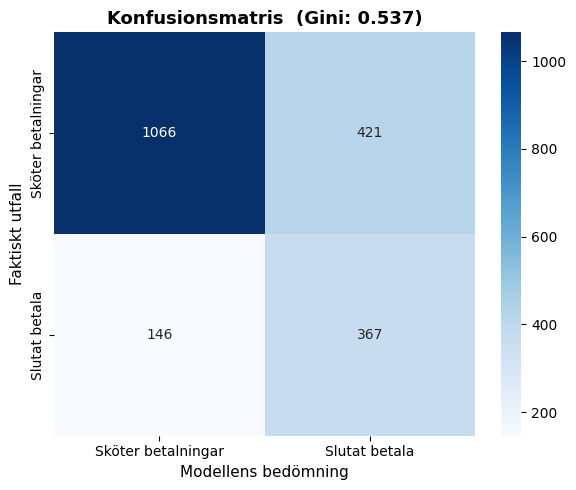

In [12]:
# Konfusionsmatris — visar hur många lån modellen klassificerade rätt respektive fel
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sköter betalningar', 'Slutat betala'],
            yticklabels=['Sköter betalningar', 'Slutat betala'])
plt.xlabel('Modellens bedömning', fontsize=11)
plt.ylabel('Faktiskt utfall', fontsize=11)
plt.title(f'Konfusionsmatris  (Gini: {gini:.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

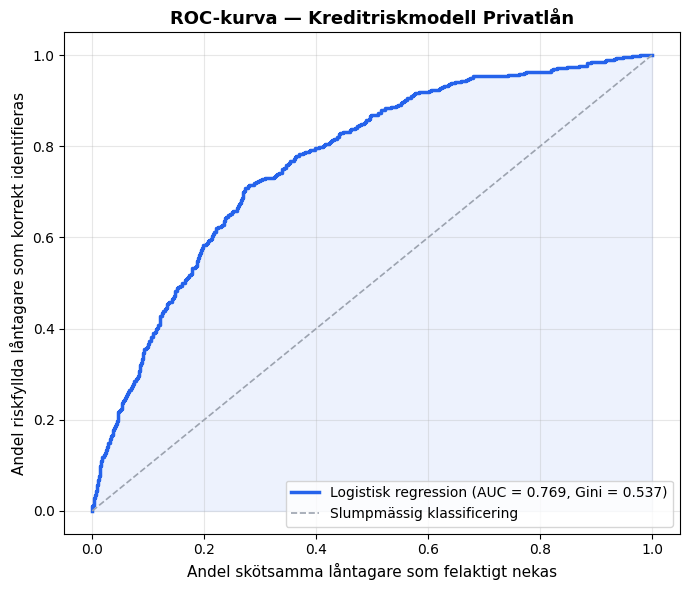

In [13]:
# ROC-kurva — visar modellens förmåga att skilja riskfyllda från skötsamma låntagare
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2563eb', linewidth=2.5,
         label=f'Logistisk regression (AUC = {auc:.3f}, Gini = {gini:.3f})')
# Diagonal = slumpmässig gissning, vår modell ska ligga klart ovanför
plt.plot([0, 1], [0, 1], color='#9ca3af', linestyle='--',
         linewidth=1.2, label='Slumpmässig klassificering')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2563eb')
plt.xlabel('Andel skötsamma låntagare som felaktigt nekas', fontsize=11)
plt.ylabel('Andel riskfyllda låntagare som korrekt identifieras', fontsize=11)
plt.title('ROC-kurva — Kreditriskmodell Privatlån', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.1 Variabelernas påverkan på risken
Koefficienterna visar vilka variabler som påverkar sannolikheten att en låntagare slutar betala.
Positiva värden ökar risken, negativa värden minskar den.

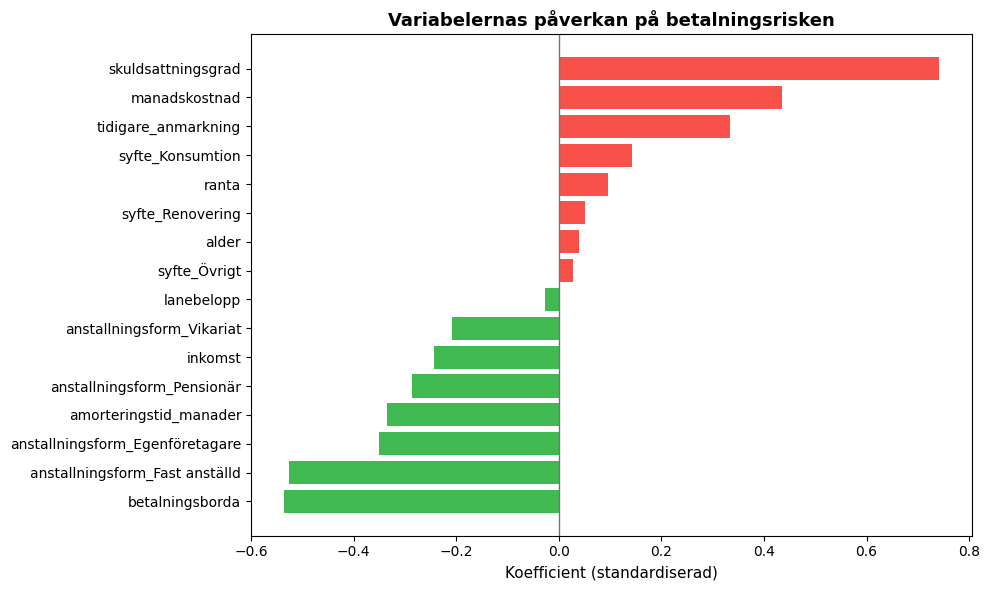


Tolkning — topp 5 som ökar risken:
  skuldsattningsgrad                       ökar risken   (+0.741)
  manadskostnad                            ökar risken   (+0.435)
  tidigare_anmarkning                      ökar risken   (+0.333)
  syfte_Konsumtion                         ökar risken   (+0.142)
  ranta                                    ökar risken   (+0.096)

Topp 5 som minskar risken:
  betalningsborda                          minskar risken (-0.536)
  anstallningsform_Fast anställd           minskar risken (-0.527)
  anstallningsform_Egenföretagare          minskar risken (-0.350)
  amorteringstid_manader                   minskar risken (-0.335)
  anstallningsform_Pensionär               minskar risken (-0.286)


In [14]:
# Skapa tabell med variabelnamn och koefficienter
importance = pd.DataFrame({
    'feature':     features,
    'koefficient': model.coef_[0]
}).sort_values('koefficient', ascending=True)

plt.figure(figsize=(10, 6))
# Röd = ökar risken, grön = minskar risken
colors = ['#f85149' if v > 0 else '#3fb950' for v in importance['koefficient']]
plt.barh(importance['feature'], importance['koefficient'], color=colors, edgecolor='none')
plt.axvline(0, color='#6e7681', linewidth=1)
plt.xlabel('Koefficient (standardiserad)', fontsize=11)
plt.title('Variabelernas påverkan på betalningsrisken', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTolkning — topp 5 som ökar risken:")
top5 = importance[importance['koefficient'] > 0].tail(5).sort_values('koefficient', ascending=False)
for _, row in top5.iterrows():
    print(f"  {row['feature']:40s} ökar risken   ({row['koefficient']:+.3f})")

print("\nTopp 5 som minskar risken:")
bot5 = importance[importance['koefficient'] < 0].head(5)
for _, row in bot5.iterrows():
    print(f"  {row['feature']:40s} minskar risken ({row['koefficient']:+.3f})")

## 7. Slutsatser

Modellen förutsäger risken att en låntagare slutar betala sitt privatlån med en **Gini-koefficient på ~0.55**, vilket är acceptabelt för kreditrisk.

**Viktigaste riskdrivare:**
- Tidigare betalningsanmärkning är den starkaste enskilda riskfaktorn
- Hög betalningsbörda (>30% av månadsinkomsten) ökar risken markant
- Arbetslösa och vikariatsanställda har betydligt högre risk än fast anställda
- Konsumtionslån har högre risk än renoverings- och billån

**Begränsningar:**
- Datan är syntetisk — i produktion tränas modellen på verklig historisk lånedata från BigQuery
- Logistisk regression är en enkel modell — mer avancerade modeller kan ge högre Gini
- Ytterligare variabler som kredithistorik och totala skulder skulle förbättra modellen

**Relevans för IFRS 9:**
- Modellen är tolkningsbar — varje variabels påverkan kan förklaras för regulatorer
- Gini-koefficienten dokumenterar modellens prestanda
- Valideringen mot testdata visar att modellen generaliserar till nya låntagare

## 8. Spara modell och scaler

In [15]:
with open('privatlan_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('privatlan_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Spara även listan med feature-namn för användning i kalkylatorn
import json
with open('privatlan_features.json', 'w') as f:
    json.dump(features, f)

print("✅ Modell, scaler och feature-lista sparade!")
print(f"   Features: {len(features)} st")
print(f"   Gini: {gini:.3f}")

✅ Modell, scaler och feature-lista sparade!
   Features: 16 st
   Gini: 0.537
